<a href="https://colab.research.google.com/github/JosephBigDataAnalytics/JKaremera-Programming-BigDataAnalytics/blob/main/Task_4_complete_FashionMNIST_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Taks 4 summary

I broke the problem down into clear, sequential steps — loading the data with torchvision.datasets.FashionMNIST, defining the ImageMLP architecture with correctly sized input (784) and output (10) layers, then writing a full training loop using nn.CrossEntropyLoss and the Adam optimizer across 10 epochs. I ensured the evaluation phase used model.eval() and torch.no_grad() for an accurate, unbiased test accuracy measurement on the 10,000 test images, and added both a training loss curve and a correct/incorrect predictions grid to fulfil the visualisation requirement. The script was structured so each section was self-contained with explanatory comments, making it easy to understand why each choice was made — such as why no softmax is needed on the output layer, and why shuffle=True is only applied to the training loader.

Task 4


Image Classification with an MLP on Fashion-MNIST

This problem tests your ability to adapt the image classification code to a new, slightly more challenging dataset. Fashion-MNIST has the same format as MNIST (28x28 grayscale images, 10 classes) but features clothing items instead of digits, making it a harder task.

Your Goal: Train an MLP to classify images of clothing from the Fashion-MNIST dataset.

Your Task:

Load Data: Use torchvision.datasets to load the FashionMNIST dataset. The process is almost identical to how you loaded MNIST. Create training and testing DataLoaders.

Define a Model: You can reuse the ImageMLP architecture from the tutorial, as the input (784) and output (10) dimensions are the same.

Train the Model: Write a training loop using nn.CrossEntropyLoss and the Adam optimizer. Train for 10 epochs.

Evaluate: Calculate and print the final accuracy on the 10,000 test images.

Visualize: Visualize a few correct and incorrect predictions.

Hint:

This is a "drop-in replacement" exercise. The vast majority of your MNIST code will work here. You only need to change torchvision.datasets.MNIST to torchvision.datasets.FashionMNIST. Pay attention to how you define and train the model—it should be a multi-class classification setup


Loading Fashion-MNIST

torchvision.datasets.FashionMNIST() handles downloading and storing the data automatically when you set download=True. The files are saved locally under a data/ folder and won't be re-downloaded on subsequent runs.
​

python

In [ ]:
# --- Imports ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np

# STEP 1: Load the Fashion-MNIST Dataset

In [ ]:
# torchvision.datasets.FashionMNIST is a drop-in replacement
# for datasets.MNIST — only the class name changes.
# root="data"     → folder where the dataset will be saved
# train=True/False → selects the 60k training or 10k test split
# download=True   → downloads the files if not already present
# transform=ToTensor() → converts PIL images to tensors scaled [0.0, 1.0]

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# Human-readable class labels for the 10 clothing categories
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print(f"Training samples : {len(training_data)}")
print(f"Test samples     : {len(test_data)}")
print(f"Image shape      : {training_data[0][0].shape}")  # → torch.Size([1, 28, 28])

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.48MB/s]

Training samples : 60000
Test samples     : 10000
Image shape      : torch.Size([1, 28, 28])


# STEP 2: Create DataLoaders

In [ ]:
# DataLoader wraps the dataset and serves mini-batches during training.
# batch_size=64  → process 64 images at a time (good balance of speed/memory)
# shuffle=True   → randomise order each epoch to prevent the model memorising
#                  the sequence (only needed for training)

train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,     batch_size=64, shuffle=False)

print(f"\nBatches in train_loader : {len(train_loader)}")
print(f"Batches in test_loader  : {len(test_loader)}")



Batches in train_loader : 938
Batches in test_loader  : 157


# STEP 3: Define the MLP Model (ImageMLP)

In [ ]:
# Architecture:
#   Input  → Flatten  → Linear(784→256) → ReLU
#          → Linear(256→128) → ReLU
#          → Linear(128→10)   ← raw logits (no softmax needed here)
#
# Why 784? Each image is 28×28 = 784 pixels. We flatten it into a 1D vector.
# Why 10 outputs? One score (logit) per clothing class.
# ReLU introduces non-linearity so the network can learn complex patterns.
# CrossEntropyLoss (used in training) applies softmax internally, so we do
# NOT add a softmax layer at the end.

class ImageMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),            # [batch, 1, 28, 28] → [batch, 784]
            nn.Linear(784, 256),     # Hidden layer 1
            nn.ReLU(),
            nn.Linear(256, 128),     # Hidden layer 2
            nn.ReLU(),
            nn.Linear(128, 10)       # Output layer — 10 class scores
        )

    def forward(self, x):
        return self.network(x)


# Use GPU if available, otherwise fall back to CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsing device: {device}")

model = ImageMLP().to(device)
print(model)


Using device: cuda
ImageMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


# STEP 4: Set Up Loss Function and Optimizer

In [ ]:
# nn.CrossEntropyLoss: the standard loss for multi-class classification.
#   Internally computes softmax + negative log-likelihood.
#   It expects raw logits from the model — NOT probabilities.
#
# Adam optimizer: an adaptive gradient descent method that adjusts the
#   learning rate per parameter. lr=1e-3 is a reliable default.

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# STEP 5: Training Loop (10 Epochs)

In [ ]:
# One epoch = one full pass through all 60,000 training images.
# For each batch we:
#   1. Move data to the correct device (CPU or GPU)
#   2. Zero out gradients from the previous step (they accumulate by default)
#   3. Forward pass  → get predictions
#   4. Compute loss  → how wrong were the predictions?
#   5. Backward pass → compute gradients via backpropagation
#   6. Optimizer step → update weights to reduce loss

NUM_EPOCHS = 10
train_losses = []   # track loss per epoch for plotting

print("\n--- Training ---")
for epoch in range(NUM_EPOCHS):
    model.train()          # puts model in training mode (enables dropout etc.)
    running_loss = 0.0

    for batch_idx, (X, y) in enumerate(train_loader):
        X, y = X.to(device), y.to(device)   # Step 1: move to device

        optimizer.zero_grad()                # Step 2: clear old gradients
        predictions = model(X)              # Step 3: forward pass
        loss = criterion(predictions, y)    # Step 4: compute loss
        loss.backward()                     # Step 5: backpropagation
        optimizer.step()                    # Step 6: update weights

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  Loss: {avg_loss:.4f}")


--- Training ---
Epoch [ 1/10]  Loss: 0.5294
Epoch [ 2/10]  Loss: 0.3724
Epoch [ 3/10]  Loss: 0.3333
Epoch [ 4/10]  Loss: 0.3080
Epoch [ 5/10]  Loss: 0.2901
Epoch [ 6/10]  Loss: 0.2738
Epoch [ 7/10]  Loss: 0.2625
Epoch [ 8/10]  Loss: 0.2495
Epoch [ 9/10]  Loss: 0.2395
Epoch [10/10]  Loss: 0.2269


# STEP 6: Evaluate on the Test Set

In [ ]:
# model.eval()        → disables dropout/batch-norm randomness
# torch.no_grad()     → disables gradient tracking (saves memory, speeds up)
# .argmax(dim=1)      → picks the class index with the highest logit score

print("\n--- Evaluating ---")
model.eval()
correct = 0
total   = len(test_data)

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)                        # raw logits
        predicted = outputs.argmax(dim=1)         # predicted class index
        correct  += (predicted == y).sum().item() # count correct predictions

accuracy = correct / total * 100
print(f"Test Accuracy: {correct}/{total}  →  {accuracy:.2f}%")


--- Evaluating ---
Test Accuracy: 8891/10000  →  88.91%


# STEP 7: Plot Training Loss Curve

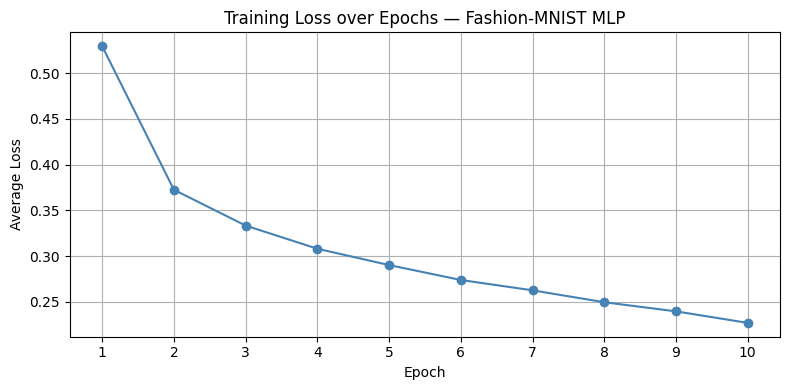

Loss curve saved → training_loss.png


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', color='steelblue')
plt.title("Training Loss over Epochs — Fashion-MNIST MLP")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.xticks(range(1, NUM_EPOCHS + 1))
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()
print("Loss curve saved → training_loss.png")

# STEP 8: Visualise Correct and Incorrect Predictions

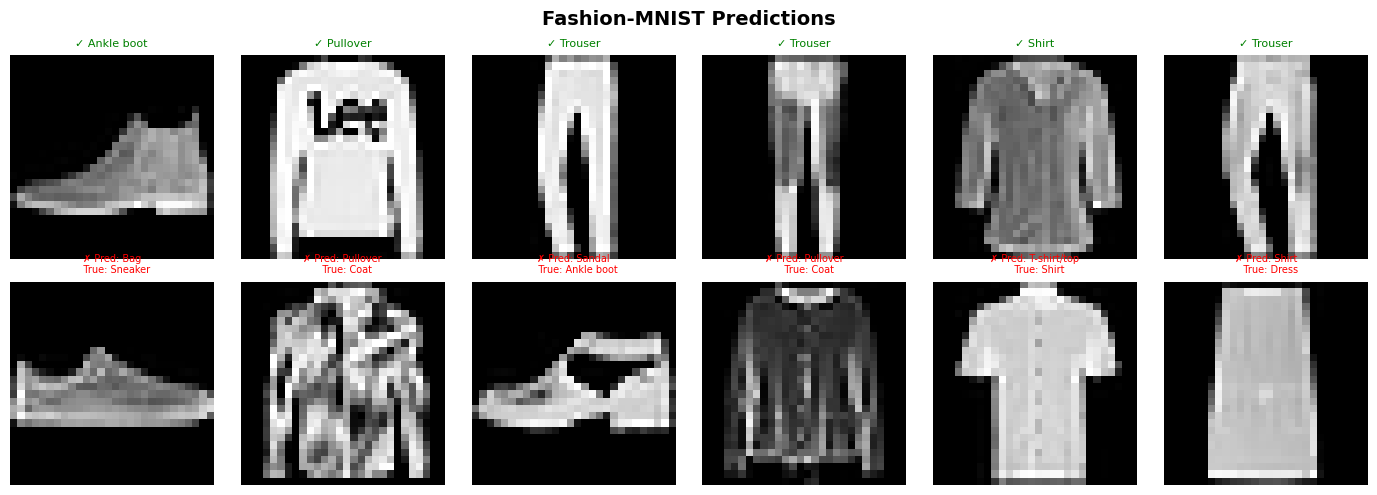

Predictions grid saved → predictions_grid.png


In [ ]:
# We collect up to 6 correct and 6 incorrect examples from the test set,
# then display them in a grid with the true and predicted labels.

model.eval()
correct_images, correct_preds, correct_labels   = [], [], []
incorrect_images, incorrect_preds, incorrect_labels = [], [], []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs   = model(X)
        predicted = outputs.argmax(dim=1)

        for i in range(len(y)):
            img   = X[i].cpu().squeeze().numpy()   # remove channel dim → [28,28]
            true  = y[i].item()
            pred  = predicted[i].item()

            if pred == true and len(correct_images) < 6:
                correct_images.append(img)
                correct_preds.append(pred)
                correct_labels.append(true)

            elif pred != true and len(incorrect_images) < 6:
                incorrect_images.append(img)
                incorrect_preds.append(pred)
                incorrect_labels.append(true)

        # Stop once we have enough examples of each type
        if len(correct_images) == 6 and len(incorrect_images) == 6:
            break

# --- Plot the grid ---
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle("Fashion-MNIST Predictions", fontsize=14, fontweight='bold')

for col in range(6):
    # Top row: correct predictions (green border)
    axes[0, col].imshow(correct_images[col], cmap='gray')
    axes[0, col].set_title(
        f"✓ {class_names[correct_preds[col]]}", color='green', fontsize=8
    )
    axes[0, col].axis('off')

    # Bottom row: incorrect predictions (red border)
    axes[1, col].imshow(incorrect_images[col], cmap='gray')
    axes[1, col].set_title(
        f"✗ Pred: {class_names[incorrect_preds[col]]}\n"
        f"   True: {class_names[incorrect_labels[col]]}",
        color='red', fontsize=7
    )
    axes[1, col].axis('off')

# Add row labels on the left
axes[0, 0].set_ylabel("Correct", fontsize=11, color='green', labelpad=10)
axes[1, 0].set_ylabel("Incorrect", fontsize=11, color='red', labelpad=10)

plt.tight_layout()
plt.savefig("predictions_grid.png", dpi=150)
plt.show()
print("Predictions grid saved → predictions_grid.png")